In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from sklearn.model_selection import KFold
from tqdm import tqdm
from pathlib import Path
from PIL import Image
from collections import defaultdict
import json, os, copy
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

WEIGHTS_DIR   = Path("weights")
TEMPORAL_DIR  = Path("dataset_temporal")
PROCESSED_DIR = Path("data/processed")
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
WINDOW_SIZE   = 3
FEAT_CHANNELS = None

WEIGHTS_DIR.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device: {DEVICE}")

Device: cpu


In [ ]:
# Load OSR Backbone from notebook 01
class OpenSetClassifier(nn.Module):
    def __init__(self, n_classes=4, energy_threshold=-10.0):
        super().__init__()
        self.backbone = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)
        for name, p in self.backbone.named_parameters():
            if not any(name.startswith(s) for s in
                       ['features.4','features.5','features.6','features.7','classifier']):
                p.requires_grad = False
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.3), nn.Linear(1536, n_classes)
        )
        self.energy_threshold = energy_threshold

    def forward(self, x):
        feat_map = self.backbone.features[:6](x)
        out      = self.backbone.features[6:](feat_map)
        out      = self.backbone.avgpool(out)
        logits   = self.backbone.classifier(out.flatten(1))
        energy   = -torch.logsumexp(logits, dim=-1)
        probs    = F.softmax(logits, dim=-1)
        conf, pred = probs.max(dim=-1)
        return {"logits": logits, "pred_class": pred, "confidence": conf,
                "energy": energy, "is_known": (energy < self.energy_threshold),
                "feature_map": feat_map}

osr_model = OpenSetClassifier(n_classes=4).to(DEVICE)
osr_model.load_state_dict(torch.load(WEIGHTS_DIR / "openset.pt", map_location=DEVICE))
osr_model.eval()
for p in osr_model.parameters():
    p.requires_grad = False

extractor = osr_model.backbone.features[:6].eval().to(DEVICE)
for p in extractor.parameters():
    p.requires_grad = False

# Cek shape output
with torch.no_grad():
    _dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
    _feat  = extractor(_dummy)
FEAT_CHANNELS = _feat.shape[1]
FEAT_H        = _feat.shape[2]
FEAT_W        = _feat.shape[3]
print(f"Feature map: [B, {FEAT_CHANNELS}, {FEAT_H}, {FEAT_W}]")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 126MB/s]


Feature map: [B, 136, 14, 14]


In [ ]:
# 3. Precompute
transform_img = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def precompute_all():
    index = []
    for kelas_dir in sorted(TEMPORAL_DIR.iterdir()):
        if not kelas_dir.is_dir(): continue
        kelas = kelas_dir.name
        seqs  = sorted(kelas_dir.iterdir())
        print(f"  {kelas}: {len(seqs)} sekuens")

        for seq_dir in seqs:
            if not seq_dir.is_dir(): continue
            meta_path = seq_dir / "metadata.json"

            meta      = json.loads(meta_path.read_text())
            spoil_day = meta["spoil_day"]
            frames    = sorted(seq_dir.glob("day_*.jpg"))

            if len(frames) < 3:
                print(f"    ⚠️  Skip {seq_dir.name} — hanya {len(frames)} frame"); continue

            feat_seq, label_seq = [], []
            with torch.no_grad():
                for fp in frames:
                    day_num = int(fp.stem.split("_")[1])
                    img_t   = transform_img(Image.open(fp).convert("RGB")).unsqueeze(0).to(DEVICE)
                    feat    = extractor(img_t).cpu().squeeze(0)       # [C, H, W]
                    feat_seq.append(feat)
                    label_seq.append(float(max(0, spoil_day - day_num)))

            seq_id   = f"{kelas}_{seq_dir.name}"
            out_path = PROCESSED_DIR / f"{seq_id}.pt"
            torch.save({
                "features":   torch.stack(feat_seq),  # [T, C, H, W]
                "labels":     label_seq,               # [T] days_remaining per frame
                "food_class": kelas,
                "spoil_day":  spoil_day,
                "seq_id":     seq_id,
                "n_frames":   len(frames)
            }, out_path)
            index.append({"seq_id": seq_id, "food_class": kelas,
                          "file": str(out_path), "n_frames": len(frames),
                          "spoil_day": spoil_day})

    with open(PROCESSED_DIR / "index.json", "w") as f:
        json.dump(index, f, indent=2)
    return index

if not (PROCESSED_DIR / "index.json").exists():
    print("Precomputing features...")
    index = precompute_all()
else:
    with open(PROCESSED_DIR / "index.json") as f:
        index = json.load(f)
    print(f"Features sudah ada: {len(index)} sekuens")

# Statistik distribusi
from collections import Counter
dist = Counter(item["food_class"] for item in index)
print(f"\nDistribusi: {dict(dist)}")
print(f"Total: {len(index)} sekuens")

Precomputing features...
  avocado: 5 sekuens
  banana: 5 sekuens
  pear: 5 sekuens
  tomato: 5 sekuens

Distribusi: {'avocado': 5, 'banana': 5, 'pear': 5, 'tomato': 5}
Total: 20 sekuens


In [ ]:
# 4. Temporal Decay Dataset Optimized
class TemporalDecayDataset(Dataset):
    """
    1. Feature noise — simulasi variasi foto
    2. Temporal jitter — skip frame acak
    3. Feature scaling — simulasi kondisi pencahayaan
    4. Channel dropout — robustkan terhadap feature partial
    """
    def __init__(self, seq_files: list, window: int = 3, augment: bool = False):
        self.window  = window
        self.augment = augment
        self.samples = []

        for fpath in seq_files:
            data   = torch.load(fpath, map_location="cpu")
            feats  = data["features"]   # [T, C, H, W]
            labels = data["labels"]     # list float
            T      = feats.shape[0]

            # Sliding window (min 3)
            for end_t in range(window, T + 1):
                x = feats[end_t - window : end_t].clone()    # [window, C, H, W]
                y = float(labels[end_t - 1])
                self.samples.append((x, y, data["food_class"]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y, kelas = self.samples[idx]
        x = x.clone()

        if self.augment:
            # 1. Gaussian noise di feature space (p=0.7)
            if torch.rand(1) < 0.7:
                noise_std = 0.02 * x.std()
                x = x + torch.randn_like(x) * noise_std

            # 2. Random feature scaling per channel (p=0.5)
            if torch.rand(1) < 0.5:
                C = x.shape[1]
                scale = 1.0 + (torch.rand(C) - 0.5) * 0.2
                x = x * scale[None, :, None, None]

            # 3. Random channel dropout (p=0.3)
            if torch.rand(1) < 0.3:
                C    = x.shape[1]
                drop = torch.rand(C) > 0.1
                x    = x * drop[None, :, None, None].float()

            # 4. Temporal flip (p=0.2)
            if torch.rand(1) < 0.2:
                x = x.flip(0)

            # 5. Label noise kecil (p=0.3)
            if torch.rand(1) < 0.3:
                y = max(0.0, y + np.random.normal(0, 0.3))

        return x, torch.tensor(y, dtype=torch.float32)


# 5. Syntetic Image Generator
def generate_synthetic_sequences(seq_files: list, n_per_seq: int = 3) -> list:
    synthetic = []
    data_pool = [torch.load(f, map_location="cpu") for f in seq_files]

    # Kelompokkan per kelas
    by_class = defaultdict(list)
    for d in data_pool:
        by_class[d["food_class"]].append(d)

    for kelas, seqs in by_class.items():
        if len(seqs) < 2:
            continue
        for _ in range(n_per_seq * len(seqs)):
            i, j = np.random.choice(len(seqs), 2, replace=False)
            seq_a, seq_b = seqs[i], seqs[j]

            T = min(seq_a["n_frames"], seq_b["n_frames"])
            fa = seq_a["features"][:T]   # [T, C, H, W]
            fb = seq_b["features"][:T]

            alpha     = np.random.uniform(0.3, 0.7)
            feat_syn  = alpha * fa + (1 - alpha) * fb

            la  = seq_a["labels"][:T]
            lb  = seq_b["labels"][:T]
            lbl = [alpha * a + (1 - alpha) * b for a, b in zip(la, lb)]

            synthetic.append({
                "features":   feat_syn,
                "labels":     lbl,
                "food_class": kelas,
                "spoil_day":  alpha * seq_a["spoil_day"] + (1-alpha) * seq_b["spoil_day"],
                "seq_id":     f"synthetic_{kelas}_{len(synthetic)}",
                "n_frames":   T,
                "is_synthetic": True
            })

    return synthetic

In [ ]:
# 6. ConvoLSTM Cell
class ConvLSTMCell(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, kernel_size: int = 3):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.conv = nn.Conv2d(
            in_channels + hidden_channels,
            4 * hidden_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            bias=True
        )
        nn.init.constant_(self.conv.bias[hidden_channels : 2 * hidden_channels], 1.0)

    def forward(self, x, h, c):
        gates    = self.conv(torch.cat([x, h], dim=1))
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        c_new = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h_new = torch.sigmoid(o) * torch.tanh(c_new)
        return h_new, c_new

    def init_hidden(self, B, H, W, device):
        z = lambda: torch.zeros(B, self.hidden_channels, H, W, device=device)
        return z(), z()


# 7. Shelf Life Predictor
class ShelfLifePredictor(nn.Module):
    """
    Lebih kecil karena dataset kecil.
    hidden1=16, hidden2=8 → total ~15K parameter.
    """
    def __init__(self, in_channels: int, hidden1: int = 16, hidden2: int = 8):
        super().__init__()
        self.cell1 = ConvLSTMCell(in_channels, hidden1)
        self.cell2 = ConvLSTMCell(hidden1,     hidden2)

        # Batch norm
        self.bn = nn.BatchNorm2d(hidden2)

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((2, 2)),
            nn.Flatten(),
            nn.Linear(hidden2 * 4, 32),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(32, 1),
            nn.Softplus() # non-negetive output
        )

    def forward(self, seq):
        B, T, C, H, W = seq.shape
        h1, c1 = self.cell1.init_hidden(B, H, W, seq.device)
        h2, c2 = self.cell2.init_hidden(B, H, W, seq.device)

        for t in range(T):
            h1, c1 = self.cell1(seq[:, t], h1, c1)
            h2, c2 = self.cell2(h1,        h2, c2)

        h2 = self.bn(h2)
        return self.head(h2)   # [B, 1]


# 8. Smoke Test
model = ShelfLifePredictor(in_channels=FEAT_CHANNELS).to(DEVICE)
_dummy_seq = torch.randn(4, WINDOW_SIZE, FEAT_CHANNELS, FEAT_H, FEAT_W).to(DEVICE)
with torch.no_grad():
    _out = model(_dummy_seq)
print(f"Output shape: {_out.shape}")   # [4, 1]
print(f"Output values: {_out.squeeze().tolist()}")  # non-negatif
total_p = sum(p.numel() for p in model.parameters())
print(f"Total params: {total_p:,} ← kecil, cocok untuk {len(index)} sekuens")

Output shape: torch.Size([4, 1])
Output values: [0.6780027747154236, 0.6692168712615967, 0.6781817078590393, 0.7111148834228516]
Total params: 95,665 ← kecil, cocok untuk 20 sekuens


In [ ]:
# 9. Calculate Loss Function
def rank_loss(pred: torch.Tensor, target: torch.Tensor, margin: float = 0.5):
    B = pred.shape[0]
    if B < 2:
        return torch.tensor(0.0, device=pred.device)
    pi = pred.unsqueeze(1).expand(B, B)
    pj = pred.unsqueeze(0).expand(B, B)
    ti = target.unsqueeze(1).expand(B, B)
    tj = target.unsqueeze(0).expand(B, B)
    mask = (ti - tj) > margin
    if mask.sum() == 0:
        return torch.tensor(0.0, device=pred.device)
    return F.relu(pj - pi + margin)[mask].mean()


def combined_loss(pred, target, alpha=0.75, beta=0.25):
    p = pred.squeeze(1)
    l1   = F.smooth_l1_loss(p, target, beta=0.5)
    rank = rank_loss(p, target)
    return alpha * l1 + beta * rank, l1.item(), rank.item()


# 10. K-Fold Training
N_FOLDS      = 5     # 5 fold = tiap fold: 4 sekuens val, 16 train (dari 20)
EPOCHS       = 120   # epoch lebih banyak karena data sedikit per fold
LR           = 2e-4
BATCH_SIZE   = 6     # batch kecil karena data sedikit

all_files    = [item["file"] for item in index]
class_labels = [item["food_class"] for item in index]

synth_data = generate_synthetic_sequences(all_files, n_per_seq=4)

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_files)):

    train_files = [all_files[i] for i in train_idx]
    val_files   = [all_files[i] for i in val_idx]
    print(f"Train: {len(train_files)} sekuens | Val: {len(val_files)} sekuens")

    train_ds_real  = TemporalDecayDataset(train_files, window=WINDOW_SIZE, augment=True)

    # Add syntetic to training set
    class SyntheticDataset(Dataset):
        def __init__(self, synth_list, window, augment=True):
            self.samples = []
            self.augment = augment
            for d in synth_list:
                feats  = d["features"]
                labels = d["labels"]
                T      = feats.shape[0]
                for end_t in range(window, T + 1):
                    x = feats[end_t-window:end_t].clone()
                    y = float(labels[end_t-1])
                    self.samples.append((x, y))

        def __len__(self): return len(self.samples)

        def __getitem__(self, idx):
            x, y = self.samples[idx]
            x = x.clone()
            if self.augment:
                if torch.rand(1) < 0.8:
                    x = x + torch.randn_like(x) * 0.03 * x.std()
            return x, torch.tensor(y, dtype=torch.float32)

    synth_ds   = SyntheticDataset(synth_data, window=WINDOW_SIZE)
    train_ds   = torch.utils.data.ConcatDataset([train_ds_real, synth_ds])
    val_ds     = TemporalDecayDataset(val_files, window=WINDOW_SIZE, augment=False)

    print(f"Samples — Train: {len(train_ds)} (real+synth) | Val: {len(val_ds)}")

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

    # Init model per fold
    fold_model = ShelfLifePredictor(in_channels=FEAT_CHANNELS).to(DEVICE)
    fold_optim = optim.AdamW(fold_model.parameters(), lr=LR, weight_decay=1e-3)
    fold_sched = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        fold_optim, T_0=40, T_mult=2, eta_min=1e-6
    )

    best_mae       = float("inf")
    best_state     = None
    patience_count = 0
    PATIENCE       = 25

    fold_history = {"train_loss": [], "val_mae": []}

    for epoch in range(1, EPOCHS + 1):
        # Train
        fold_model.train()
        ep_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            fold_optim.zero_grad()
            pred = fold_model(xb)
            loss, _, _ = combined_loss(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(fold_model.parameters(), 1.0)
            fold_optim.step()
            ep_loss += loss.item()
        fold_sched.step()

        # Val
        fold_model.eval()
        preds_list, targets_list = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                p = fold_model(xb.to(DEVICE)).squeeze(1).cpu()
                preds_list.append(p)
                targets_list.append(yb)

        preds_t   = torch.cat(preds_list)
        targets_t = torch.cat(targets_list)
        val_mae   = F.l1_loss(preds_t, targets_t).item()

        fold_history["train_loss"].append(ep_loss / max(len(train_loader), 1))
        fold_history["val_mae"].append(val_mae)

        if val_mae < best_mae:
            best_mae   = val_mae
            best_state = copy.deepcopy(fold_model.state_dict())
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= PATIENCE:
            print(f"  Early stop di epoch {epoch}")
            break

        if epoch % 20 == 0:
            print(f"  Epoch {epoch:3d} | loss={ep_loss/len(train_loader):.4f} "
                  f"| val_MAE={val_mae:.3f} | best={best_mae:.3f}")

    fold_results.append({
        "fold":      fold + 1,
        "best_mae":  best_mae,
        "state":     best_state,
        "history":   fold_history
    })
    print(f"  Fold {fold+1} best MAE: {best_mae:.3f} hari")

Membuat synthetic sequences...
Synthetic sequences dibuat: 80

FOLD 1/5
Train: 16 sekuens | Val: 4 sekuens
Samples — Train: 733 (real+synth) | Val: 35
  Epoch  20 | loss=0.0916 | val_MAE=0.167 | best=0.167
  Epoch  40 | loss=0.0716 | val_MAE=0.105 | best=0.105
  Epoch  60 | loss=0.0780 | val_MAE=0.121 | best=0.089
  Epoch  80 | loss=0.0613 | val_MAE=0.276 | best=0.085
  Early stop di epoch 96
  Fold 1 best MAE: 0.085 hari

FOLD 2/5
Train: 16 sekuens | Val: 4 sekuens
Samples — Train: 740 (real+synth) | Val: 28
  Epoch  20 | loss=0.1229 | val_MAE=0.157 | best=0.098
  Epoch  40 | loss=0.1039 | val_MAE=0.170 | best=0.098
  Early stop di epoch 42
  Fold 2 best MAE: 0.098 hari

FOLD 3/5
Train: 16 sekuens | Val: 4 sekuens
Samples — Train: 732 (real+synth) | Val: 36
  Epoch  20 | loss=0.1239 | val_MAE=0.162 | best=0.158
  Epoch  40 | loss=0.0988 | val_MAE=0.147 | best=0.114
  Early stop di epoch 60
  Fold 3 best MAE: 0.114 hari

FOLD 4/5
Train: 16 sekuens | Val: 4 sekuens
Samples — Train: 737 

In [ ]:
# 11. Get Best Fold
maes  = [r["best_mae"] for r in fold_results]
mean_mae = np.mean(maes)
std_mae  = np.std(maes)

print(f"\nHasil K-Fold:")
for r in fold_results:
    print(f"  Fold {r['fold']}: MAE = {r['best_mae']:.3f}")

best_fold = fold_results[np.argmin(maes)]

torch.save(best_fold["state"], WEIGHTS_DIR / "convlstm.pt")


Hasil K-Fold:
  Fold 1: MAE = 0.085
  Fold 2: MAE = 0.098
  Fold 3: MAE = 0.114
  Fold 4: MAE = 0.058
  Fold 5: MAE = 0.082

Mean MAE : 0.087 ± 0.018 hari
Fold terbaik: Fold 4 (MAE=0.058)
Tersimpan: weights/convlstm.pt


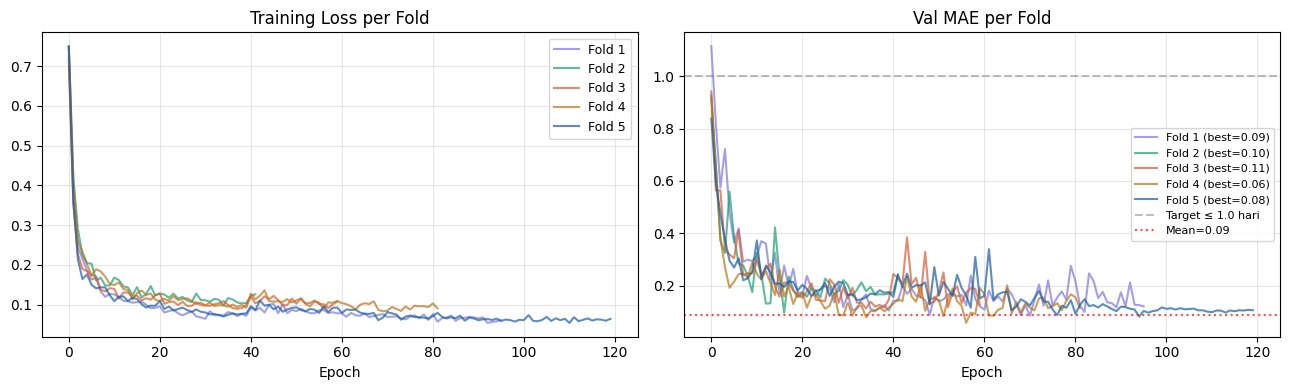

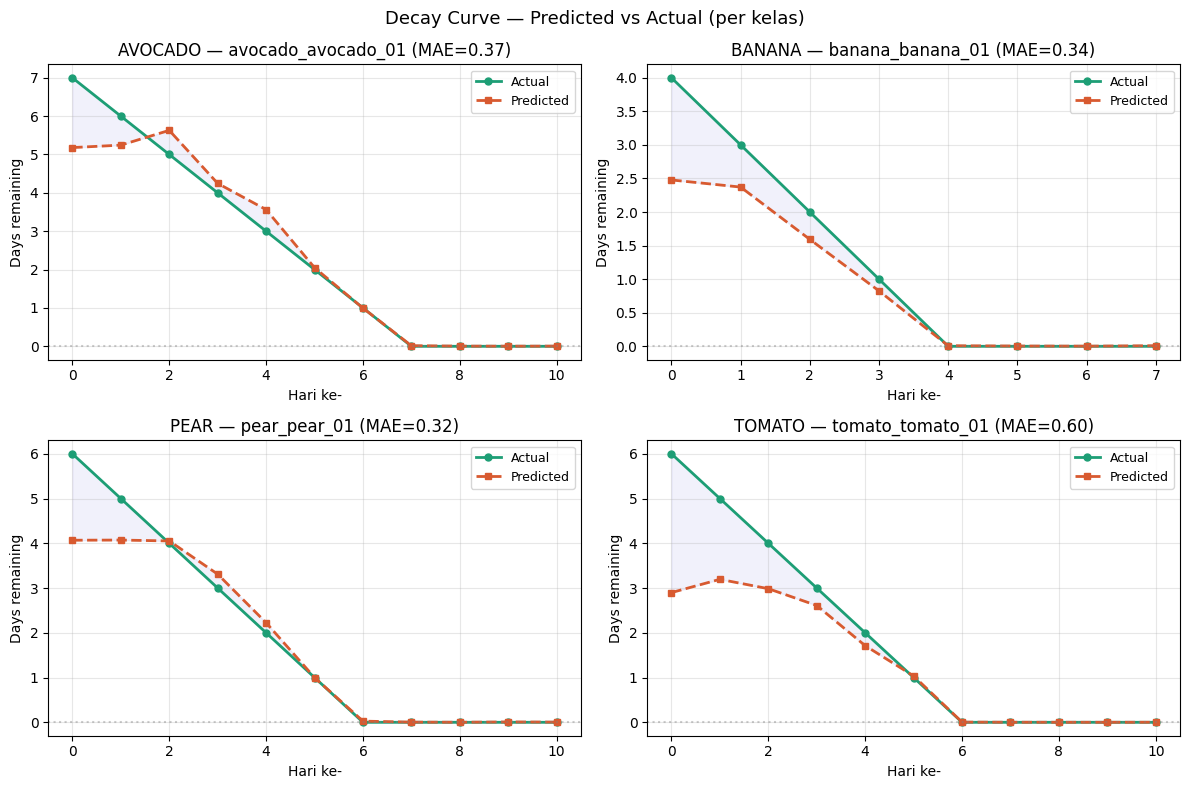

EVALUASI FINAL (semua sekuens)
  MAE  : 0.433 hari
  RMSE : 0.877 hari
  K-Fold Mean MAE: 0.087 ± 0.018

  avocado     : MAE = 0.518 hari
  banana      : MAE = 0.404 hari
  pear        : MAE = 0.377 hari
  tomato      : MAE = 0.428 hari


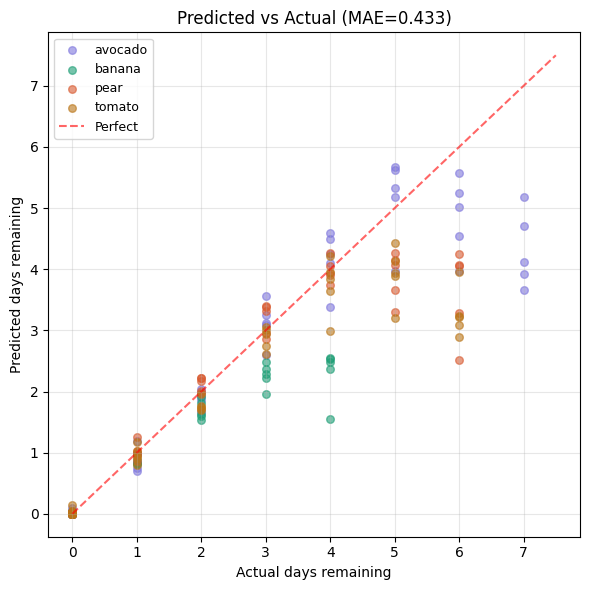

In [ ]:
# 12. Training Curve Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ["#7F77DD", "#1D9E75", "#D85A30", "#BA7517", "#185FA5"]

for r in fold_results:
    c = colors[r["fold"] - 1]
    axes[0].plot(r["history"]["train_loss"], color=c, alpha=0.7,
                 label=f"Fold {r['fold']}", linewidth=1.5)
    axes[1].plot(r["history"]["val_mae"],    color=c, alpha=0.7,
                 label=f"Fold {r['fold']} (best={r['best_mae']:.2f})", linewidth=1.5)

axes[0].set_title("Training Loss per Fold")
axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="Target ≤ 1.0 hari")
axes[1].axhline(y=mean_mae, color="red", linestyle=":", alpha=0.7,
                label=f"Mean={mean_mae:.2f}")
axes[1].set_title("Val MAE per Fold")
axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(WEIGHTS_DIR / "kfold_curves.png"), dpi=120)
plt.show()


# 13. Decay Curve Plot (avocado, banana, pear, tomato)
final_model = ShelfLifePredictor(in_channels=FEAT_CHANNELS).to(DEVICE)
final_model.load_state_dict(torch.load(WEIGHTS_DIR / "convlstm.pt", map_location=DEVICE))
final_model.eval()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Get sample
samples_to_plot = []
seen_classes = set()

for item in index:
    if item["food_class"] not in seen_classes:
        samples_to_plot.append(item)
        seen_classes.add(item["food_class"])
        if len(samples_to_plot) == 4:
            break

for ax_idx, item in enumerate(samples_to_plot):
    data   = torch.load(item["file"], map_location="cpu")
    feats  = data["features"]
    labels = data["labels"]
    T      = feats.shape[0]

    preds = []
    for end_t in range(1, T + 1):
        start_t = max(0, end_t - WINDOW_SIZE)
        x = feats[start_t:end_t]
        if x.shape[0] < WINDOW_SIZE:
            pad = feats[0:1].expand(WINDOW_SIZE - x.shape[0], -1, -1, -1)
            x   = torch.cat([pad, x], dim=0)
        with torch.no_grad():
            pred = final_model(x.unsqueeze(0).to(DEVICE)).item()
        preds.append(max(0, pred))

    ax = axes[ax_idx]
    ax.plot(range(T), labels, "o-",  color="#1D9E75", label="Actual",    linewidth=2, markersize=5)
    ax.plot(range(T), preds,  "s--", color="#D85A30", label="Predicted", linewidth=2, markersize=5)
    ax.axhline(y=0, color="gray", linestyle=":", alpha=0.4)
    ax.fill_between(range(T), labels, preds, alpha=0.1, color="#7F77DD")
    ax.set_xlabel("Hari ke-")
    ax.set_ylabel("Days remaining")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    mae_seq = np.mean(np.abs(np.array(preds) - np.array(labels)))
    ax.set_title(f"{item['food_class'].upper()} — {item['seq_id']} (MAE={mae_seq:.2f})")

plt.suptitle("Decay Curve — Predicted vs Actual (per kelas)", fontsize=13)
plt.tight_layout()
plt.savefig(str(WEIGHTS_DIR / "decay_curves_all_classes.png"), dpi=120)
plt.show()


# 14. Evaulation and Scatter Plot
all_preds_eval, all_targets_eval, all_classes_eval = [], [], []

for item in index:
    data   = torch.load(item["file"], map_location="cpu")
    feats  = data["features"]
    labels = data["labels"]
    T      = feats.shape[0]
    kelas  = data["food_class"]

    for end_t in range(1, T + 1):
        start_t = max(0, end_t - WINDOW_SIZE)
        x = feats[start_t:end_t]
        if x.shape[0] < WINDOW_SIZE:
            pad = feats[0:1].expand(WINDOW_SIZE - x.shape[0], -1, -1, -1)
            x   = torch.cat([pad, x], dim=0)
        with torch.no_grad():
            pred = final_model(x.unsqueeze(0).to(DEVICE)).item()
        all_preds_eval.append(max(0, pred))
        all_targets_eval.append(float(labels[end_t - 1]))
        all_classes_eval.append(kelas)

preds_np   = np.array(all_preds_eval)
targets_np = np.array(all_targets_eval)

mae_final  = np.mean(np.abs(preds_np - targets_np))
rmse_final = np.sqrt(np.mean((preds_np - targets_np) ** 2))

for kelas in sorted(set(all_classes_eval)):
    mask  = np.array(all_classes_eval) == kelas
    k_mae = np.mean(np.abs(preds_np[mask] - targets_np[mask]))
    print(f"  {kelas:<12}: MAE = {k_mae:.3f} hari")
print("=" * 50)

# Scatter plot
plt.figure(figsize=(6, 6))
for kelas, color in zip(sorted(set(all_classes_eval)), colors):
    mask = np.array(all_classes_eval) == kelas
    plt.scatter(targets_np[mask], preds_np[mask], label=kelas,
                s=30, alpha=0.6, color=color)
max_val = max(targets_np.max(), preds_np.max()) + 0.5
plt.plot([0, max_val], [0, max_val], "r--", alpha=0.6, label="Perfect")
plt.xlabel("Actual days remaining")
plt.ylabel("Predicted days remaining")
plt.title(f"Predicted vs Actual (MAE={mae_final:.3f})")
plt.legend(fontsize=9); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(WEIGHTS_DIR / "scatter_final.png"), dpi=120)
plt.show()

In [1]:
# 15. Save Config
config = {
    "in_channels":   FEAT_CHANNELS,
    "hidden1":       16,
    "hidden2":       8,
    "window_size":   WINDOW_SIZE,
    "feat_h":        FEAT_H,
    "feat_w":        FEAT_W,
    "best_fold_mae": round(float(best_fold["best_mae"]), 4),
    "kfold_mean_mae":round(float(mean_mae), 4),
    "kfold_std_mae": round(float(std_mae), 4),
    "n_classes":     4,
    "n_folds":       N_FOLDS
}
with open(WEIGHTS_DIR / "convlstm_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Config:")
print(json.dumps(config, indent=2))

NameError: name 'FEAT_CHANNELS' is not defined